In [1]:
print("Hellou")

Hellou


In [2]:
import pandas as pd

df = pd.read_csv("8class_data.csv")
df.columns = df.columns.str.strip()

print(df.shape)
print(df.columns.tolist())

(3317513, 47)
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


In [3]:
label_col = 'label'  # adjust once you see the actual column name
print(df[label_col].value_counts())

label
2    2415365
3     574352
4     186924
0      78222
6      34771
5      25232
7       1747
1        900
Name: count, dtype: int64


In [4]:
label_map = {
    0: 'Benign',
    1: 'BruteForce',
    2: 'DDoS',
    3: 'DoS',
    4: 'Mirai',
    5: 'Recon',
    6: 'Spoofing',
    7: 'Web'
}

df['label_name'] = df[label_col].map(label_map)
print(df['label_name'].value_counts())

label_name
DDoS          2415365
DoS            574352
Mirai          186924
Benign          78222
Spoofing        34771
Recon           25232
Web              1747
BruteForce        900
Name: count, dtype: int64


In [5]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(df.shape)

(3317513, 48)


In [6]:
print(df['label_name'].value_counts())

label_name
DDoS          2415365
DoS            574352
Mirai          186924
Benign          78222
Spoofing        34771
Recon           25232
Web              1747
BruteForce        900
Name: count, dtype: int64


In [7]:
X = df.drop(columns=[label_col], errors='ignore')
y = df[label_col]

In [8]:
X = df.drop(columns=[label_col, 'label_name'], errors='ignore')

In [9]:
print(X.dtypes.value_counts())
print(X.select_dtypes(include='object').columns.tolist())

float64    46
Name: count, dtype: int64
[]


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(2322259, 46) (995254, 46)


In [11]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [12]:
print(y_pred[:10])
print(len(y_pred))

[2 2 2 2 2 2 2 2 6 4]
995254


              precision    recall  f1-score   support

           0       0.91      0.98      0.94     23467
           1       1.00      0.32      0.48       270
           2       1.00      1.00      1.00    724609
           3       1.00      1.00      1.00    172306
           4       1.00      1.00      1.00     56077
           5       0.88      0.80      0.84      7570
           6       0.90      0.85      0.87     10431
           7       0.94      0.24      0.38       524

    accuracy                           1.00    995254
   macro avg       0.95      0.77      0.81    995254
weighted avg       1.00      1.00      1.00    995254



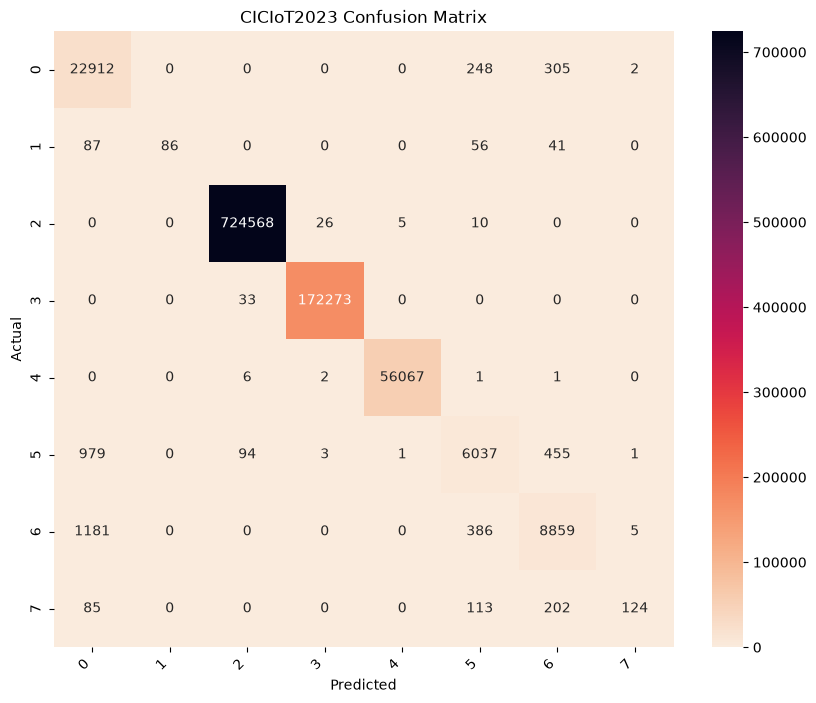

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='rocket_r')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('CICIoT2023 Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

In [14]:
# Check for exact duplicate rows in the full dataset
dupe_count = df.duplicated(subset=X.columns.tolist()).sum()
print(f"Exact duplicate feature-rows: {dupe_count} out of {len(df)} ({dupe_count/len(df)*100:.1f}%)")

# Check specifically within DDoS
ddos_rows = df[df['label_name'] == 'DDoS']
ddos_dupes = ddos_rows.duplicated(subset=X.columns.tolist()).sum()
print(f"DDoS duplicate rows: {ddos_dupes} out of {len(ddos_rows)} ({ddos_dupes/len(ddos_rows)*100:.1f}%)")

Exact duplicate feature-rows: 506535 out of 3317513 (15.3%)
DDoS duplicate rows: 457586 out of 2415365 (18.9%)


In [15]:
# Drop exact duplicate rows based on features (keep first occurrence)
df_dedup = df.drop_duplicates(subset=X.columns.tolist())
print(f"Before: {len(df)} rows, After dedup: {len(df_dedup)} rows")
print(df_dedup['label_name'].value_counts())

# Rebuild X and y from the deduplicated data
X_dedup = df_dedup.drop(columns=[label_col, 'label_name'], errors='ignore')
y_dedup = df_dedup[label_col]

# Fresh stratified split, same settings as before
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_dedup, y_dedup, test_size=0.3, random_state=42, stratify=y_dedup
)
print(X_train2.shape, X_test2.shape)

# Retrain from scratch on deduplicated data
model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)

print(classification_report(y_test2, y_pred2))

Before: 3317513 rows, After dedup: 2810978 rows
label_name
DDoS          1957779
DoS            530324
Mirai          182045
Benign          78217
Spoofing        34760
Recon           25206
Web              1747
BruteForce        900
Name: count, dtype: int64
(1967684, 46) (843294, 46)
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     23465
           1       1.00      0.32      0.49       270
           2       1.00      1.00      1.00    587334
           3       1.00      1.00      1.00    159097
           4       1.00      1.00      1.00     54614
           5       0.88      0.80      0.84      7562
           6       0.90      0.85      0.87     10428
           7       0.93      0.24      0.39       524

    accuracy                           0.99    843294
   macro avg       0.95      0.77      0.82    843294
weighted avg       0.99      0.99      0.99    843294



IAT              0.489641
Min              0.042347
flow_duration    0.040692
Magnitue         0.039794
AVG              0.037574
Protocol Type    0.035345
Max              0.035068
Tot sum          0.030656
Header_Length    0.027562
Tot size         0.022614
Rate             0.022522
urg_count        0.021826
Srate            0.020248
rst_count        0.019434
Variance         0.015870
dtype: float64


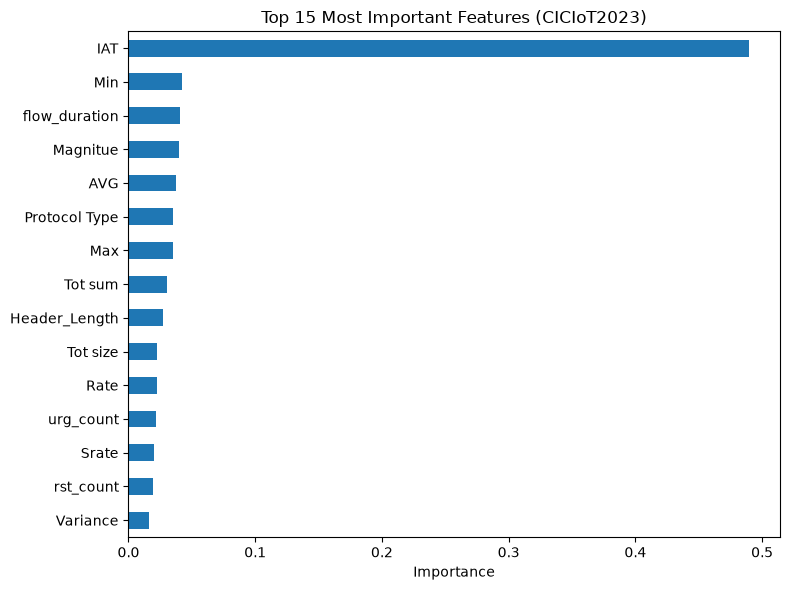

In [16]:
importances = pd.Series(model2.feature_importances_, index=X_dedup.columns)
top_features = importances.sort_values(ascending=False).head(15)
print(top_features)

plt.figure(figsize=(8, 6))
top_features.plot(kind='barh')
plt.title('Top 15 Most Important Features (CICIoT2023)')
plt.xlabel('Importance'); plt.gca().invert_yaxis(); plt.tight_layout()
plt.show()

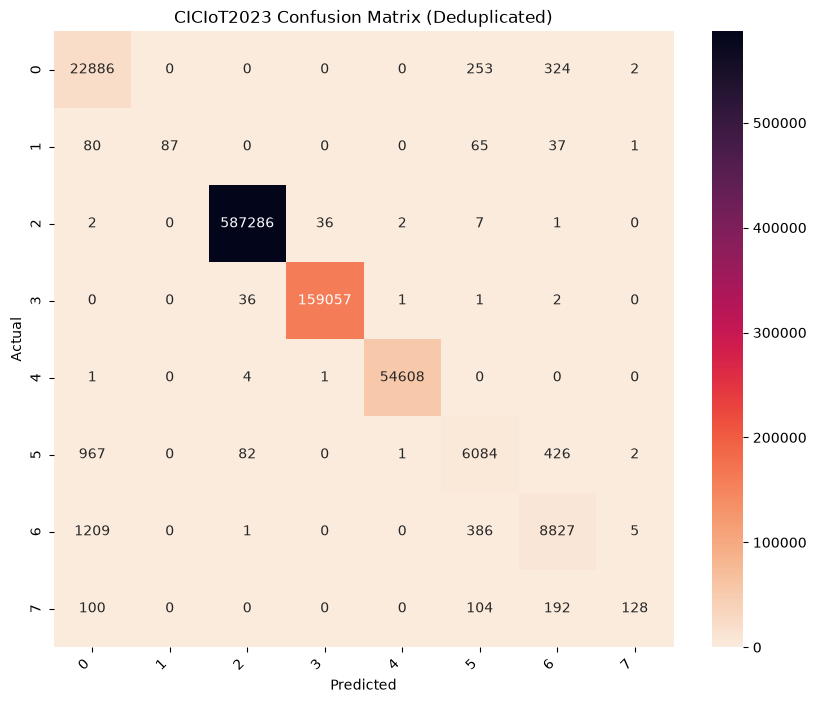

In [17]:
cm2 = confusion_matrix(y_test2, y_pred2, labels=model2.classes_)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=model2.classes_, yticklabels=model2.classes_, cmap='rocket_r')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('CICIoT2023 Confusion Matrix (Deduplicated)')
plt.xticks(rotation=45, ha='right')
plt.show()

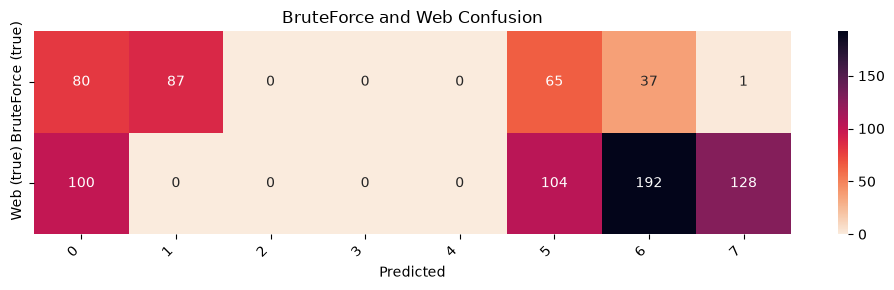

In [19]:
# Pull out just the BruteForce (1) and Web (7) rows from the full confusion matrix
classes = model2.classes_.tolist()
rows_of_interest = [classes.index(1), classes.index(7)]  # BruteForce=1, Web=7

cm_zoom = cm2[rows_of_interest, :]

plt.figure(figsize=(10, 3))
sns.heatmap(cm_zoom, annot=True, fmt='d',
            xticklabels=model2.classes_,
            yticklabels=['BruteForce (true)', 'Web (true)'],
            cmap='rocket_r')
plt.xlabel('Predicted'); plt.title('BruteForce and Web Confusion')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()